<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
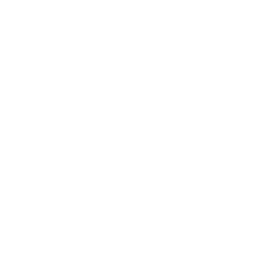
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Μείωση Διαστασιμότητας Μετρικών Ποιότητας</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Κατασκευή / Έλεγχος Διεργασίας &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για τη Διοίκηση

Μια γραμμή παραγωγής αυτοκινητιστικών εξαρτημάτων καταγράφει 12 μετρικές ποιοτικού ελέγχου ανά εξάρτημα — τέσσερα διαστασιακά όργανα μέτρησης, τέσσερις μετρήσεις ποιότητας επιφάνειας και τέσσερις δοκιμές αντοχής υλικού. Επειδή τα όργανα εντός κάθε ομάδας κινούνται μαζί, οι 12 ακατέργαστες μετρικές μεταφέρουν πολύ λιγότερες από 12 διαστάσεις πληροφορίας. Το σημειωματάριο αυτό χρησιμοποιεί την **PROC FACTOR** (εξαγωγή κύριου άξονα με τετράγωνες πολλαπλές συσχετίσεις ως εκ των προτέρων κοινότητες, `PRIORS=SMC`) για να συμπιέσει τις 12 μετρικές σε ένα μικρό σύνολο ορθογώνιων παραγόντων κατάλληλο για πολυμεταβλητή παρακολούθηση διεργασίας.

Στα 100 επιθεωρημένα εξαρτήματα που είναι διαθέσιμα σε αυτό το περιβάλλον, το συνολικό μέτρο επάρκειας δειγματοληψίας Kaiser-Meyer-Olkin είναι **0.85**, και τρεις παράγοντες αναπαράγουν το **91.3%** της διακύμανσης με μια σαφή θραύση στο διάγραμμα scree μετά τον τρίτο — ανακτώντας καθαρά τις ομαδοποιήσεις διαστάσεων, αντοχής και επιφάνειας. Οι βαθμολογίες παραγόντων που διατηρούνται περνούν στη συνέχεια στην **PROC CLUSTER** (μέθοδος Ward) για αναζήτηση ομαδοποιήσεων σε επίπεδο εξαρτήματος στον μειωμένο χώρο.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.QUALITY_METRICS | 12 μετρήσεις επιθεώρησης συν μεταδεδομένα βάρδιας/γραμμής/χειριστή, μία γραμμή ανά εξάρτημα | 100 |

Τα δεδομένα δημιουργούνται συνθετικά από τρεις ανεξάρτητες λανθάνουσες διαστάσεις (διαστασιακή ακρίβεια, ποιότητα επιφάνειας, αντοχή υλικού), ώστε η δομή των παραγόντων να είναι γνωστή εκ των προτέρων και η ανακτημένη λύση να μπορεί να ελεγχθεί έναντι της πραγματικής δομής. Αυτό το περιβάλλον περιορίζει την έξοδο σε 100 παρατηρήσεις, οπότε ο βρόχος `DO` παράγει 500 εξαρτήματα αλλά η ανάλυση εκτελείται στα πρώτα 100.

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών μετρήσεων ποιοτικού ελέγχου
   12 μετρικές από 3 ΑΝΕΞΑΡΤΗΤΕΣ λανθάνουσες διαστάσεις·
   αναλύονται τα πρώτα 100 από τα 500 εξαρτήματα (όριο εξόδου)
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.quality_metrics;
    CALL streaminit(42);
    LENGTH shift $30;
    ARRAY lines[4] $6 _temporary_ ('LINE1' 'LINE2' 'LINE3' 'LINE4');
    ΕΠΑΝΑΛΗΨΗ part_id = 1 ΕΩΣ 500;
        shift_idx = int(rand('uniform') * 3) + 1;
        ΕΑΝ shift_idx = 1 ΤΟΤΕ shift = 'ΠΡΩΪΝΗ';
        ΑΛΛΙΩΣ ΕΑΝ shift_idx = 2 ΤΟΤΕ shift = 'ΑΠΟΓΕΥΜΑΤΙΝΗ';
        ΑΛΛΙΩΣ shift = 'ΝΥΧΤΕΡΙΝΗ';
        line_idx = int(rand('uniform') * 4) + 1;
        prod_line = lines[line_idx];
        operator_id = cat('OP-', PUT(int(rand('uniform') * 30) + 1, z3.));
        inspection_date = '01JAN2026'd + int(rand('uniform') * 60);

        /* --- Παράγοντας διαστασιακής ακρίβειας --- */
        dim_base = rand('normal', 0, 1);
        length_mm      = round(150.0 + 0.5 * dim_base + rand('normal', 0, 0.12), 0.001);
        width_mm       = round(75.0 + 0.3 * dim_base + rand('normal', 0, 0.08), 0.001);
        thickness_mm   = round(12.0 + 0.15 * dim_base + rand('normal', 0, 0.04), 0.001);
        bore_diameter   = round(25.0 + 0.2 * dim_base + rand('normal', 0, 0.05), 0.001);

        /* --- Παράγοντας ποιότητας επιφάνειας --- */
        surf_base = rand('normal', 0, 1);
        surface_roughness = round(MAX(0.1, 1.6 + 0.4 * surf_base + rand('normal', 0, 0.15)), 0.001);
        coating_thickness = round(MAX(0.5, 8.0 + 0.8 * surf_base + rand('normal', 0, 0.3)), 0.001);
        gloss_index       = round(MAX(10, 85 - 5 * surf_base + rand('normal', 0, 2)), 0.1);
        defect_count      = MAX(0, round(2 + 1.5 * surf_base + rand('normal', 0, 0.8)));

        /* --- Παράγοντας αντοχής υλικού --- */
        str_base = rand('normal', 0, 1);
        tensile_strength  = round(MAX(200, 450 + 30 * str_base + rand('normal', 0, 10)), 0.1);
        hardness_hrc      = round(MAX(20, 58 + 4 * str_base + rand('normal', 0, 1.5)), 0.1);
        yield_point       = round(MAX(150, 380 + 25 * str_base + rand('normal', 0, 8)), 0.1);
        elongation_pct    = round(MAX(1, 12 + 2 * str_base + rand('normal', 0, 1)), 0.1);

        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ dim_base surf_base str_base shift_idx line_idx;
    ΜΟΡΦΗ inspection_date date9.;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.quality_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.quality_metrics (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.21 seconds
  cpu   0.21 seconds


---

   Pearson Correlation Coefficients, N = 100
          Prob > |r| under H0: Rho=0
           length_mm  width_mmthickness_mmbore_diametersurface_roughnesscoating_thicknessgloss_indexdefect_counttensile_strengthhardness_hrcyield_pointelongation_pct
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------
length_mm   1.00000   0.95387   0.94610   0.94834  -0.02280   0.05592  -0.00322   0.01776   0.00316  -0.00637   0.01689   0.00974
              .       <.0001    <.0001    <.0001    0.8218    0.5805    0.9746    0.8608    0.9751    0.9499    0.8676    0.9234
width_mm   0.95387   1.00000   0.94796   0.94784  -0.07471  -0.01371   0.06755  -0.05251   0.00931   0.00957   0.02390   0.03043
            <.0001      .       <.0001    <.0001    0.4601    0.8923    0.5043    0.6038    0.9267    0.9247    0.8134    0.7638
thickness_mm   0.94610   0.94796   1.00000   0.94054  -0.06727   0.01705   0.05266  -0.06345  -0.01870  -0


NOTE: PROC CORR data=work.quality_metrics

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


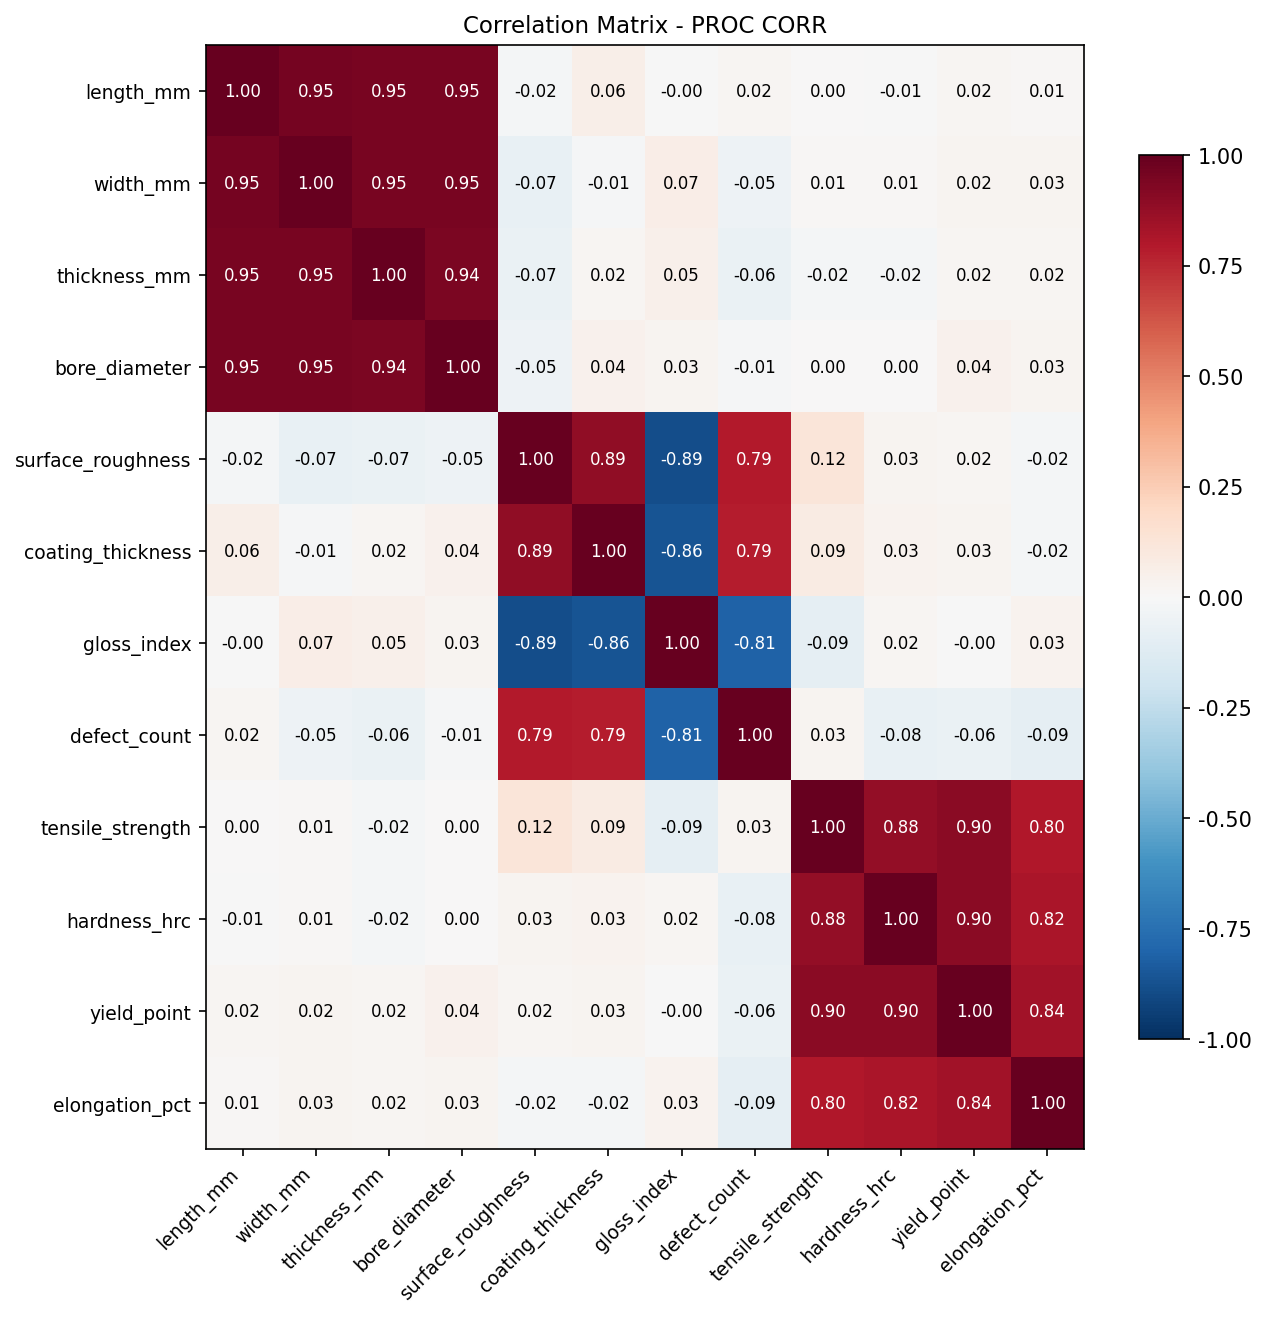

In [2]:
/* --------------------------------------------------------
   Πίνακας συσχετίσεων για επαλήθευση πολυσυγγραμμικότητας
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ CORR ΔΕΔΟΜΕΝΑ=work.quality_metrics nosimple;
    ΜΕΤΑΒΛΗΤΗ length_mm width_mm thickness_mm bore_diameter
        surface_roughness coating_thickness gloss_index defect_count
        tensile_strength hardness_hrc yield_point elongation_pct;
ΕΚΤΕΛΕΣΗ;

---


Eigenvalues of the Correlation Matrix
             Eigenvalue   Difference   Proportion   Cumulative
  Factor 1       3.8756       0.2774       0.3230       0.3230
  Factor 2       3.5982       0.1163       0.2998       0.6228
  Factor 3       3.4818       3.2319       0.2902       0.9130
  Factor 4       0.2499       0.0356       0.0208       0.9338
  Factor 5       0.2143       0.0605       0.0179       0.9516
  Factor 6       0.1539       0.0406       0.0128       0.9645
  Factor 7       0.1133       0.0175       0.0094       0.9739
  Factor 8       0.0958       0.0179       0.0080       0.9819
  Factor 9       0.0779       0.0223       0.0065       0.9884
 Factor 10       0.0557       0.0120       0.0046       0.9930
 Factor 11       0.0436       0.0035       0.0036       0.9967
 Factor 12       0.0401       0.0000       0.0033       1.0000

Factor Pattern
                Factor1    Factor2    Factor3
Μήκος (mm)      -0.9820     0.0003    -0.0274
Πλάτος (mm)     -0.9812     0.0141


NOTE: PROC FACTOR data=work.quality_metrics

NOTE: Using Python numpy version 2.4.4
NOTE: ODS plot written: factor_scree.spec.json
NOTE: PROC FACTOR completed.


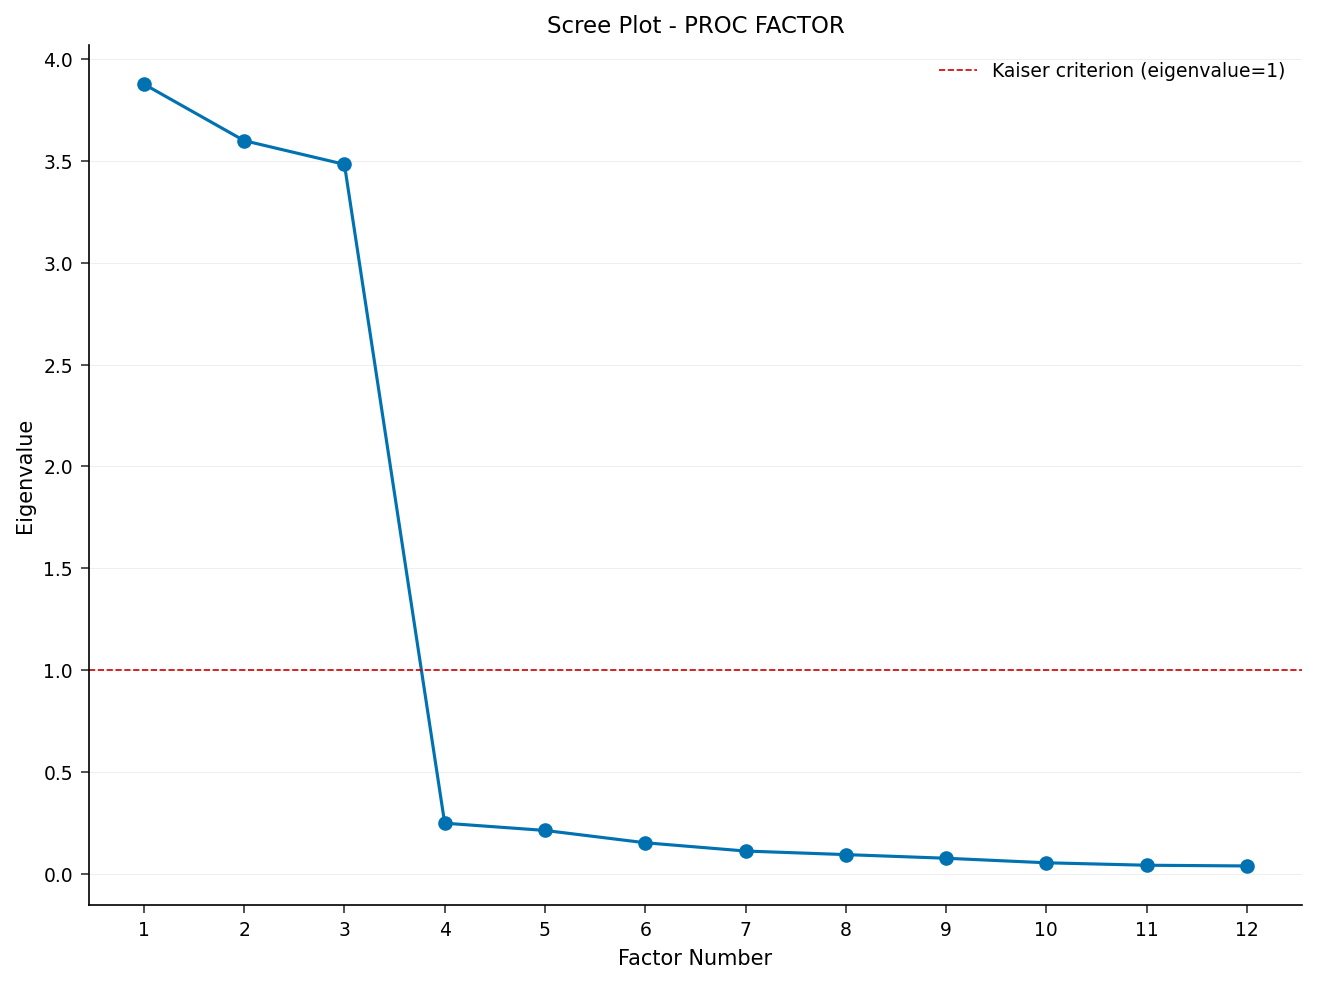

In [3]:
/* --------------------------------------------------------
   Δοκιμή MSA για επαλήθευση επάρκειας δειγματοληψίας
   PRIORS=SMC για εκτίμηση κοινοτήτων
   Ανάλυση κύριου άξονα με περιστροφή VARIMAX
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ FACTOR ΔΕΔΟΜΕΝΑ=work.quality_metrics
    METHOD=principal
    PRIORS=smc
    NFACTORS=3
    ROTATE=varimax
    MSA
    flag=0.4
    reorder
    out=work.quality_factors;
    ΜΕΤΑΒΛΗΤΗ length_mm width_mm thickness_mm bore_diameter
        surface_roughness coating_thickness gloss_index defect_count
        tensile_strength hardness_hrc yield_point elongation_pct;
    ΕΤΙΚΕΤΑ length_mm="Μήκος (mm)" width_mm="Πλάτος (mm)" thickness_mm="Πάχος (mm)"
          bore_diameter="Διάμετρος οπής (mm)" surface_roughness="Τραχύτητα επιφάνειας"
          coating_thickness="Πάχος επίστρωσης" gloss_index="Δείκτης στιλπνότητας"
          defect_count="Αριθμός ελαττωμάτων" tensile_strength="Εφελκυστική αντοχή"
          hardness_hrc="Σκληρότητα (HRC)" yield_point="Όριο διαρροής"
          elongation_pct="Επιμήκυνση (%)";
ΕΚΤΕΛΕΣΗ;

---


NOTE: PROC SGPLOT data=work.quality_factors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


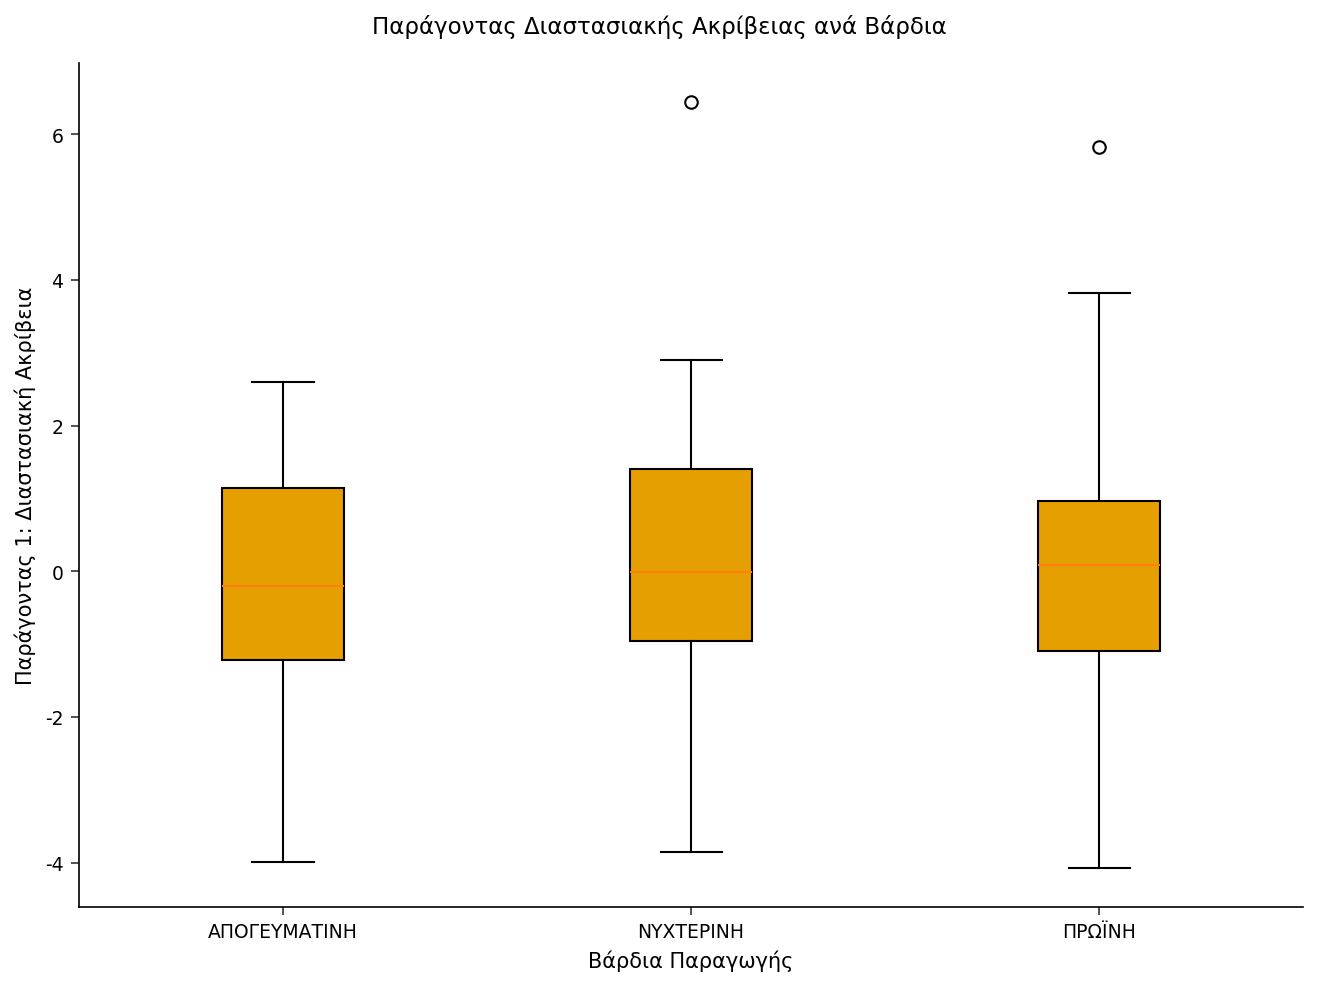

In [4]:
/* --------------------------------------------------------
   Βαθμολογία Παράγοντα 1 (διαστασιακή ακρίβεια) ανά βάρδια
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.quality_factors;
    VBOX factor1 / category=shift;
    YAXIS ΕΤΙΚΕΤΑ="Παράγοντας 1: Διαστασιακή Ακρίβεια";
    XAXIS ΕΤΙΚΕΤΑ="Βάρδια Παραγωγής";
    TITLE "Παράγοντας Διαστασιακής Ακρίβειας ανά Βάρδια";
ΕΚΤΕΛΕΣΗ;

                                                 The CLUSTER Procedure
                                        Ward's Minimum Variance Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    51                81              2    0.0000    1.0000        0.3
    98    88                98              2    0.0000    0.9999        0.3
    97    76                85              2    0.0000    0.9999        0.3
    96    82                91              2    0.0001    0.9998        0.3
    95    18                20              2    0.0001    0.9997        0.4
    94    4                 23              2    0.0001    0.9996        0.5
    93    25                30              2    0.0001    0.9995        0.5
    92    8                 39              2    0.0001    0.9994        0.5
 


NOTE: PROC CLUSTER data=work.quality_factors method=Ward

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 3 variables clustered using Ward method


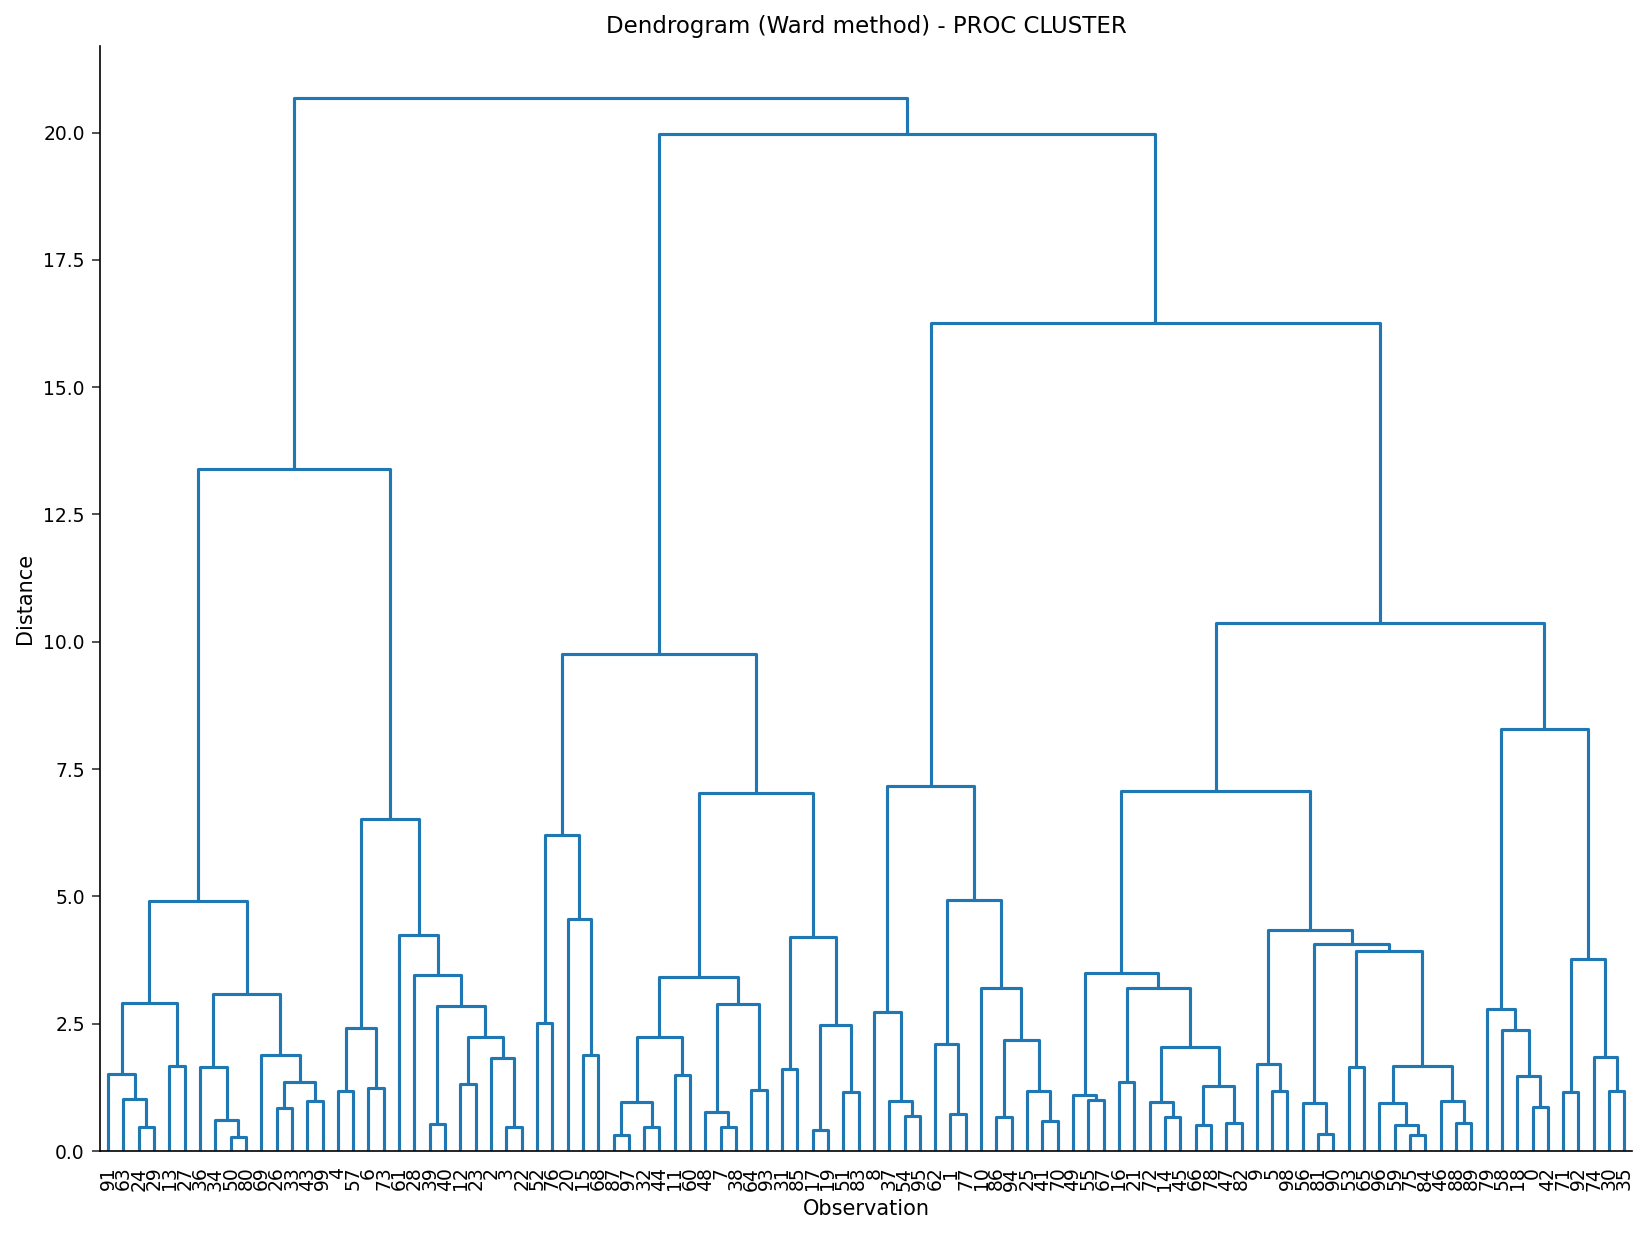

In [5]:
/* --------------------------------------------------------
   Πέρασμα βαθμολογιών παραγόντων σε ιεραρχική ομαδοποίηση
   για ανίχνευση μοτίβων ελαττωμάτων ανά βάρδια
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ CLUSTER ΔΕΔΟΜΕΝΑ=work.quality_factors
    METHOD=ward
    outtree=work.quality_tree
    print=15;
    ΜΕΤΑΒΛΗΤΗ factor1 factor2 factor3;
    id part_id;
    ΕΤΙΚΕΤΑ factor1="Παράγοντας 1" factor2="Παράγοντας 2" factor3="Παράγοντας 3";
ΕΚΤΕΛΕΣΗ;

---

### Ερμηνεία

Το συνολικό μέτρο επάρκειας δειγματοληψίας Kaiser-Meyer-Olkin είναι **0.85**, άνετα πάνω από το κατώφλι του 0.50, οπότε οι 12 μετρικές μοιράζονται αρκετή κοινή διακύμανση ώστε να δικαιολογείται η ανάλυση παραγόντων. Οι ιδιοτιμές του πίνακα συσχετίσεων είναι **3.88, 3.60 και 3.48** για τους πρώτους τρεις παράγοντες και έπειτα καταρρέουν σε **0.25 και κάτω** — μια χαρακτηριστική θραύση scree που δείχνει ξεκάθαρα σε μια λύση τριών παραγόντων. Αυτοί οι τρεις παράγοντες αναπαράγουν το **91.3%** της συνολικής διακύμανσης (32.1% + 29.9% + 29.4%)· οι υπόλοιποι εννέα παράγοντες αντιστοιχούν μαζί σε λιγότερο από 9%.

Το μοτίβο των παραγόντων ανακτά ακριβώς τις τρεις ομάδες μετρήσεων:

- Ο **Παράγοντας 1** φορτίζει στα τέσσερα διαστασιακά όργανα — μήκος, πλάτος, πάχος και διάμετρο οπής (φορτίσεις γύρω στο 0.98 σε απόλυτη τιμή) — και σε τίποτα άλλο.
- Ο **Παράγοντας 2** φορτίζει στις τέσσερις δοκιμές αντοχής — εφελκυστική αντοχή, σκληρότητα, όριο διαρροής και επιμήκυνση (0.91 έως 0.96).
- Ο **Παράγοντας 3** φορτίζει στις τέσσερις μετρήσεις επιφάνειας — τραχύτητα επιφάνειας, πάχος επίστρωσης, δείκτης στιλπνότητας και αριθμός ελαττωμάτων — με τη στιλπνότητα να έχει αντίθετο πρόσημο (0.95) από την τραχύτητα και το πάχος επίστρωσης (-0.94, -0.95), ακριβώς όπως υπονοεί η σχέση «πιο λεία επιφάνεια = υψηλότερη στιλπνότητα».

Οι διασταυρούμενες φορτίσεις είναι αμελητέες (όλες κάτω από 0.10), οπότε η περιστραμμένη δομή είναι καθαρή και κάθε αρχική μετρική αντιστοιχεί σε έναν μόνο παράγοντα. Οι τελικές κοινότητες κυμαίνονται από **0.82 (αριθμός ελαττωμάτων) έως 0.97 (μήκος, πλάτος)**, που σημαίνει ότι οι τρεις παράγοντες εξηγούν τουλάχιστον το 82% κάθε επιμέρους μετρικής.

Περνώντας τις τρεις βαθμολογίες παραγόντων στην ιεραρχική ομαδοποίηση κατά Ward παράγεται το παραπάνω δενδρόγραμμα. Επειδή οι τρεις λανθάνουσες διαστάσεις δημιουργήθηκαν ανεξάρτητα, τα εξαρτήματα δεν διαχωρίζονται σε σφιχτές, καλά απομονωμένες ομάδες — οι μεγαλύτερες αποστάσεις συγχώνευσης αυξάνονται ομαλά αντί να πηδούν σε ένα προφανές σημείο κοπής — το οποίο είναι το αναμενόμενο αποτέλεσμα όταν δεν υπάρχει γνήσια δομή υποπληθυσμού. Ο παράγοντας διαστασιακής ακρίβειας επίσης δεν δείχνει συστηματική διαφορά μεταξύ βαρδιών (θηκόγραμμα παραπάνω), συνεπές με μια διεργασία που παραμένει υπό έλεγχο και στις τρεις βάρδιες. Το πρακτικό συμπέρασμα: ο πίνακας επιθεώρησης 12 μετρικών μπορεί να παρακολουθείται με μόλις τρεις ορθογώνιες μεταβλητές ελέγχου χωρίς απώλεια ουσιαστικής πληροφορίας.

---

In [6]:
/* --------------------------------------------------------
   Εξαγωγή βαθμολογιών παραγόντων ποιότητας με αναθέσεις ομάδων
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.quality_factors
    OUTFILE='quality_factor_scores.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.quality_factors outfile=quality_factor_scores.csv

NOTE: Exported 100 rows to quality_factor_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>